# Prac 06.1
## Детекція облич за допомогою dlib

### Step 0. Імпорт бібліотек

In [16]:
%pip install dlib-bin

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import cv2
import dlib
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [12, 8]

### Step 1. Завантаження зображення

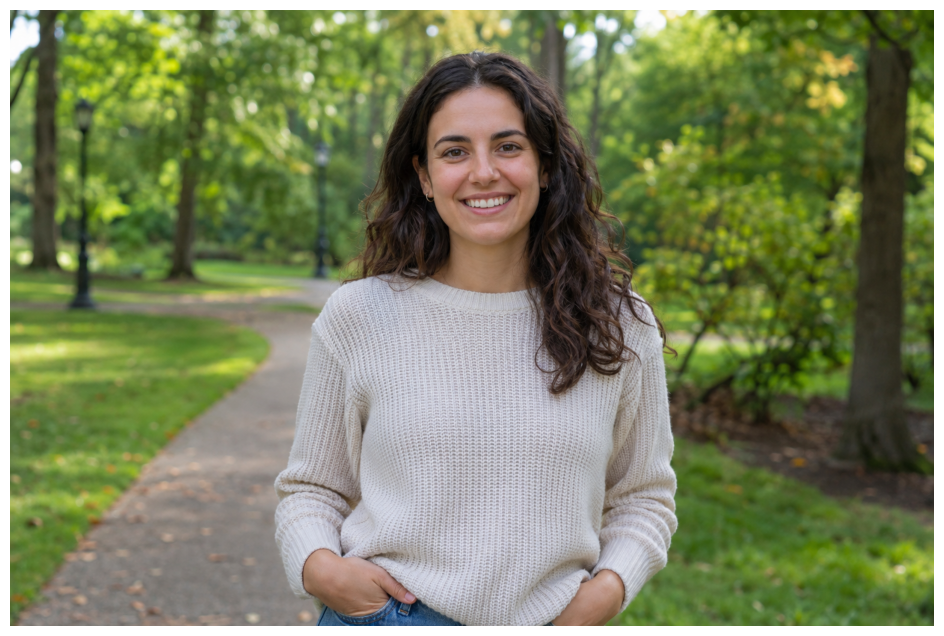

In [18]:
img = cv2.imread('woman.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(img)
plt.axis('off')
plt.show()

### Step 2. Завантаження детектора dlib

In [19]:
detector = dlib.get_frontal_face_detector()

### Step 3. Пошук облич на зображенні

In [20]:
faces = detector(gray, 1)
print('Кількість знайдених облич на зображені:', len(faces))

Кількість знайдених облич на зображені: 2


### Step 4. Виділення знайдених облич

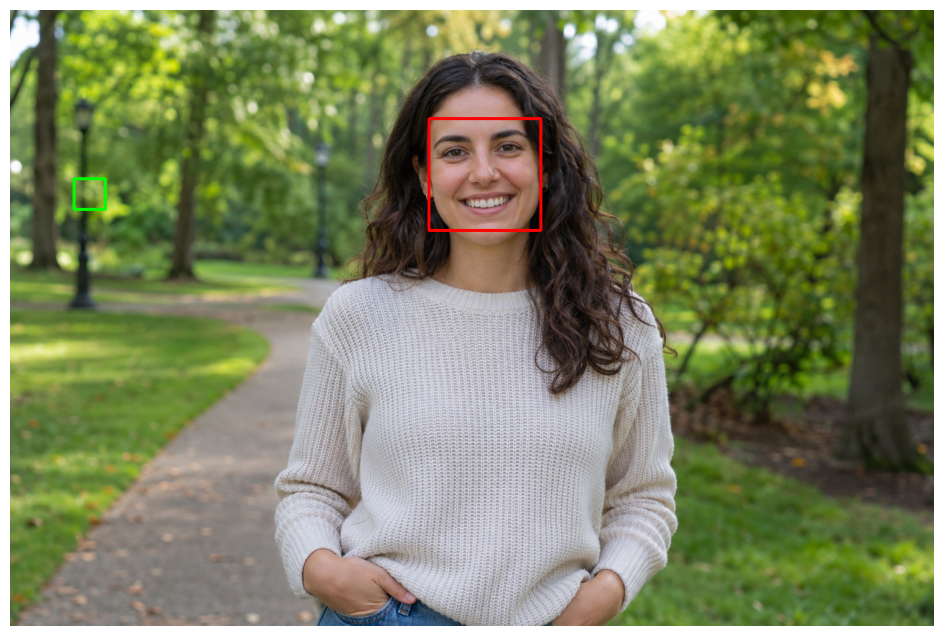

In [21]:
result = np.copy(img)
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255),
          (255, 255, 0), (255, 0, 255), (0, 255, 255),
          (255, 128, 0), (128, 0, 255)]

for i, face in enumerate(faces):
    x1, y1 = face.left(), face.top()
    x2, y2 = face.right(), face.bottom()
    color = colors[i % len(colors)]
    cv2.rectangle(result, (x1, y1), (x2, y2), color, 3)

plt.imshow(result)
plt.axis('off')
plt.show()

### Step 5. Додаткове завдання
Перевіримо детектор на складнішому зображенні з більшою кількістю людей і меншими обличчями.

Кількість знайдених облич на фото: 41


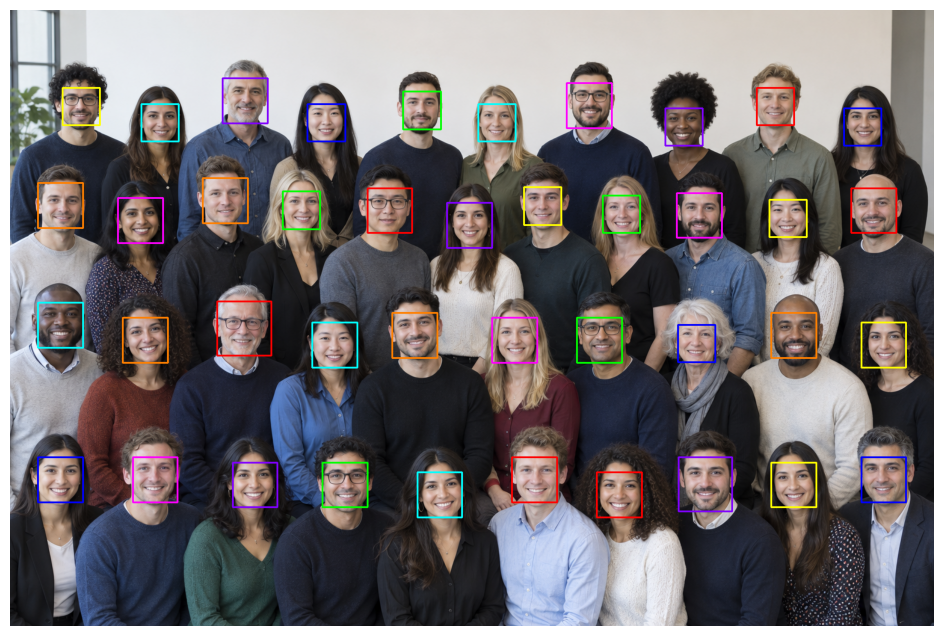

In [22]:
img2 = cv2.imread('people.png')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

faces2 = detector(gray2, 1)
result2 = np.copy(img2)

for i, face in enumerate(faces2):
    x1, y1 = face.left(), face.top()
    x2, y2 = face.right(), face.bottom()
    color = colors[i % len(colors)]
    cv2.rectangle(result2, (x1, y1), (x2, y2), color, 2)

print('Кількість знайдених облич на фото:', len(faces2))
plt.imshow(result2)
plt.axis('off')
plt.show()